In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
job_title = 'Data Scientist'
df_chosen_job = df[df['job_title_short'] == job_title].copy()
df_chosen_job['month_num'] = df_chosen_job['job_posted_date'].dt.month


In [3]:
df_chosen_job = df_chosen_job.explode('job_skills')

In [4]:
df_chosen_job_pivot = df_chosen_job.pivot_table(index='month_num', columns='job_skills', aggfunc='size', fill_value=0)

In [5]:
df_chosen_job_pivot.loc['Total'] = df_chosen_job_pivot.sum()

In [6]:
df_chosen_job_pivot = df_chosen_job_pivot[df_chosen_job_pivot.loc['Total'].sort_values(ascending=False).index]

In [7]:
df_chosen_job_pivot = df_chosen_job_pivot.drop('Total')

In [8]:
df_chosen_job_pivot = df_chosen_job_pivot.reset_index()

In [9]:
df_chosen_job_pivot['job_posted_month'] = df_chosen_job_pivot['month_num'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))

In [10]:
df_chosen_job_pivot.set_index('job_posted_month', inplace=True)

In [11]:
df_chosen_job_pivot = df_chosen_job_pivot.drop('month_num', axis=1)

In [12]:
df_chosen_job_pivot

job_skills,python,sql,r,sas,tableau,aws,spark,azure,tensorflow,excel,...,huggingface,fastify,esquisse,workfront,play framework,wimi,shogun,mattermost,nuxt.js,sqlserver
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,13998,9811,7566,3842,3446,3253,3222,2582,2316,2132,...,0,0,0,0,0,0,0,0,0,0
Feb,9551,6600,5064,2644,2566,2089,2085,1716,1525,1453,...,0,0,1,0,0,0,0,0,0,0
Mar,9210,6374,4971,2480,2456,2092,1992,1727,1405,1440,...,0,0,0,1,0,0,1,0,0,0
Apr,9135,6270,4873,2444,2447,2055,1905,1665,1546,1456,...,0,2,0,0,0,0,0,0,0,0
May,8029,5583,4228,2244,2271,1921,1716,1442,1271,1202,...,0,0,0,0,0,0,0,0,0,0
Jun,9338,6473,5019,2282,2432,2173,2072,1739,1580,1324,...,0,1,1,0,0,0,0,0,0,0
Jul,9400,6678,5029,2300,2547,2207,1972,1845,1535,1425,...,1,0,0,0,0,0,0,0,0,0
Aug,11193,8026,6089,3100,3013,2571,2466,2130,1972,1795,...,0,0,0,0,1,0,0,0,0,0
Sep,8393,5748,4153,2224,2062,1923,1820,1704,1462,1352,...,3,0,0,0,0,0,0,0,0,0


Text(0, 0.5, 'Count')

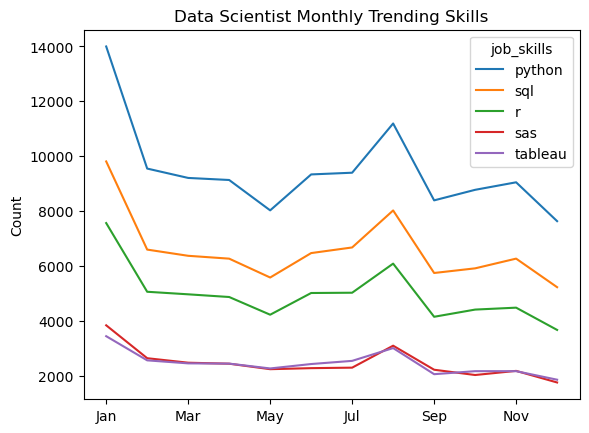

In [13]:
df_chosen_job_pivot.iloc[:,:5].plot(kind='line')
plt.title(f'{job_title} Monthly Trending Skills')
plt.xlabel('')
plt.ylabel('Count')